In [15]:
import sys
!{sys.executable} -m pip install seaborn

222.02s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")  # makes all plots look clean automatically
print("Libraries loaded ✓")

Libraries loaded ✓


In [17]:
df = pd.read_csv("Titanic-Dataset.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nMissing as percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

In [20]:
df.drop(columns=["Cabin"], inplace=True)

df["Age"].fillna(df["Age"].median(), inplace=True)

df.dropna(subset=["Embarked"], inplace=True)

# Confirm — should all be 0
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nNew shape:", df.shape)

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

New shape: (889, 11)


/var/folders/90/3k1jqn6x4kq3fg9lm9x6ny3h0000gn/T/ipykernel_73003/3558967804.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)


Overall survival rate: 38.2%


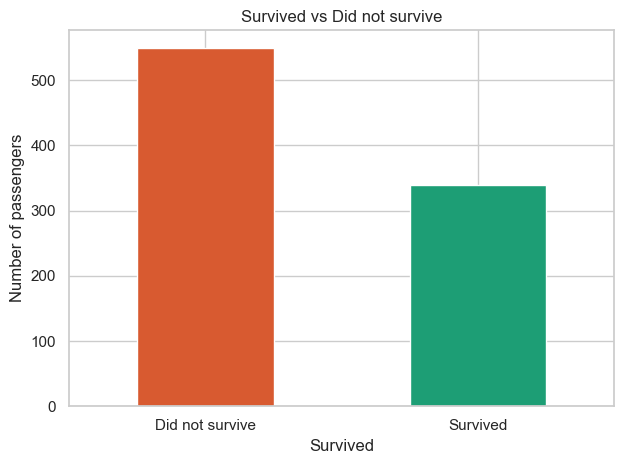

In [22]:
survival_rate = df["Survived"].mean() * 100
print(f"Overall survival rate: {survival_rate:.1f}%")

# Visualise
df["Survived"].value_counts().plot(kind="bar", color=["#D85A30","#1D9E75"])
plt.title("Survived vs Did not survive")
plt.xticks([0, 1], ["Did not survive", "Survived"], rotation=0)
plt.ylabel("Number of passengers")
plt.tight_layout()
plt.show()


Survival rate by class:
Pclass
1    62.6
2    47.3
3    24.2
Name: Survived, dtype: float64


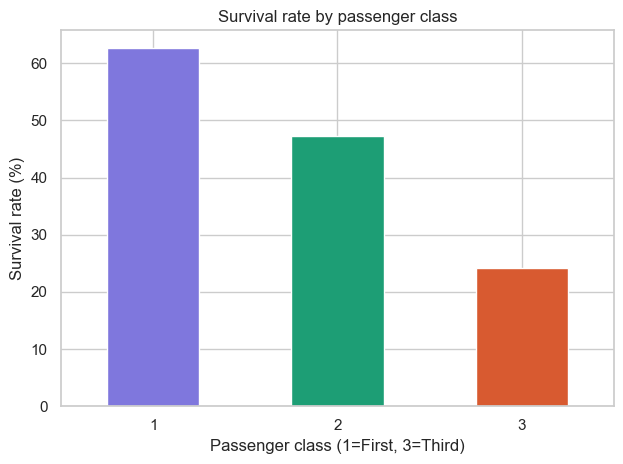

In [24]:
pclass_survival = df.groupby("Pclass")["Survived"].mean() * 100
print("Survival rate by class:")
print(pclass_survival.round(1))

pclass_survival.plot(kind="bar", color=["#7F77DD","#1D9E75","#D85A30"])
plt.title("Survival rate by passenger class")
plt.xlabel("Passenger class (1=First, 3=Third)")
plt.ylabel("Survival rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Survival rate by gender:
Sex
female    74.0
male      18.9
Name: Survived, dtype: float64


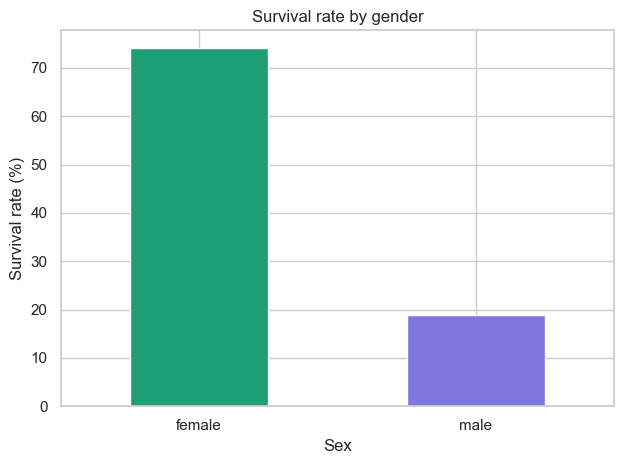

In [25]:
gender_survival = df.groupby("Sex")["Survived"].mean() * 100
print("Survival rate by gender:")
print(gender_survival.round(1))

gender_survival.plot(kind="bar", color=["#1D9E75", "#7F77DD"])
plt.title("Survival rate by gender")
plt.ylabel("Survival rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


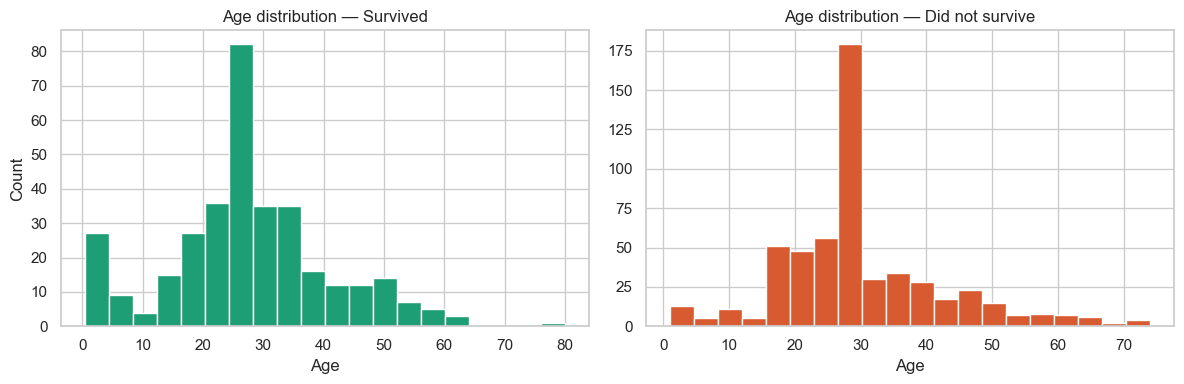

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Survivors
axes[0].hist(df[df["Survived"]==1]["Age"], bins=20, color="#1D9E75", edgecolor="white")
axes[0].set_title("Age distribution — Survived")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

# Did not survive
axes[1].hist(df[df["Survived"]==0]["Age"], bins=20, color="#D85A30", edgecolor="white")
axes[1].set_title("Age distribution — Did not survive")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

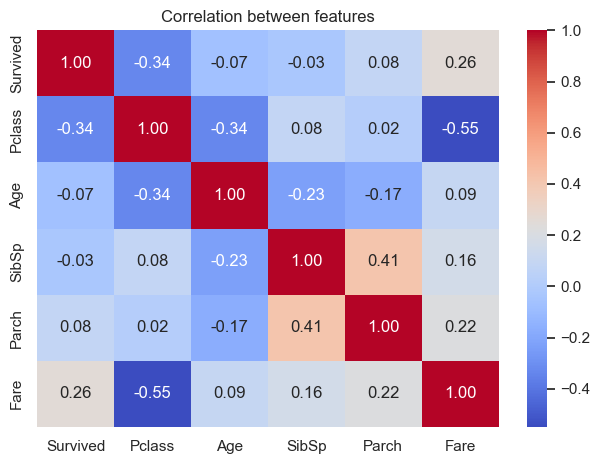

In [28]:
numeric_cols = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]]

sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between features")
plt.tight_layout()
plt.show()

In [29]:
print("=" * 45)
print("       TITANIC EDA — KEY FINDINGS")
print("=" * 45)
print(f"Total passengers analysed: {len(df)}")
print(f"Overall survival rate: {df['Survived'].mean()*100:.1f}%")
print(f"Best surviving class: {df.groupby('Pclass')['Survived'].mean().idxmin()} class")
print(f"Female survival rate: {df[df['Sex']=='female']['Survived'].mean()*100:.1f}%")
print(f"Male survival rate:   {df[df['Sex']=='male']['Survived'].mean()*100:.1f}%")
print(f"Median age of survivors: {df[df['Survived']==1]['Age'].median():.1f} yrs")
print("=" * 45)

       TITANIC EDA — KEY FINDINGS
Total passengers analysed: 889
Overall survival rate: 38.2%
Best surviving class: 3 class
Female survival rate: 74.0%
Male survival rate:   18.9%
Median age of survivors: 28.0 yrs


In [30]:
git remote add origin https://github.com/chiragGit47/titanic-eda.git
git branch -M main
git push -u origin main

SyntaxError: invalid syntax (1433665555.py, line 1)